# Data Understanding

Tahap ini melakukan eksplorasi awal (EDA) terhadap dataset 200 artikel berita yang telah dikumpulkan pada tahap Business Understanding, untuk memastikan data siap digunakan pada tahap selanjutnya (Data Preparation & Modeling).

In [1]:
import pandas as pd

df = pd.read_excel("../data/dataset_berita_200.xlsx")
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (200, 4)


,id,isi_berita,label,url
0,1,Chef de Mission (CdM) Indonesia Todotua Pasari...,sport,https://sport.detik.com/sport-lain/d-8655308/c...
1,2,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport,https://sport.detik.com/sport-lain/d-8655303/a...
2,3,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport,https://sport.detik.com/sport-lain/d-8655067/k...
3,4,Persaingan titel juara dunia semakin ketat men...,sport,https://sport.detik.com/moto-gp/d-8654776/moto...
4,5,Sektor ganda campuran kembali mengalami peromb...,sport,https://sport.detik.com/raket/d-8654666/ganda-...


In [2]:
print("Info dataset:")
df.info()

print("\nDistribusi label:")
print(df["label"].value_counts())

print("\nCek nilai kosong:")
print(df.isnull().sum())

print("\nCek duplikat isi_berita:")
print(df["isi_berita"].duplicated().sum())

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    int64 
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: int64(1), object(3)
memory usage: 6.4+ KB

Distribusi label:
label
sport      100
finance    100
Name: count, dtype: int64

Cek nilai kosong:
id            0
isi_berita    0
label         0
url           0
dtype: int64

Cek duplikat isi_berita:
0


In [3]:
df["panjang_teks"] = df["isi_berita"].apply(len)

print("Statistik panjang teks (karakter):")
print(df.groupby("label")["panjang_teks"].describe())

Statistik panjang teks (karakter):
         count     mean          std    min     25%     50%      75%     max
label                                                                       
finance  100.0  2596.74  1327.979308  826.0  1874.5  2291.0  2863.75  8169.0
sport    100.0  2274.33   812.942343  996.0  1704.0  2131.5  2630.50  5554.0


In [5]:
import sys

!{sys.executable} -m pip install matplotlib

     ---------------------------------------- 8.2/8.2 MB 4.9 MB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 70.6/70.6 kB 1.3 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 3.6 MB/s eta 0:00:00
     -------------------------------------- 221.2/221.2 kB 4.5 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 5.8 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


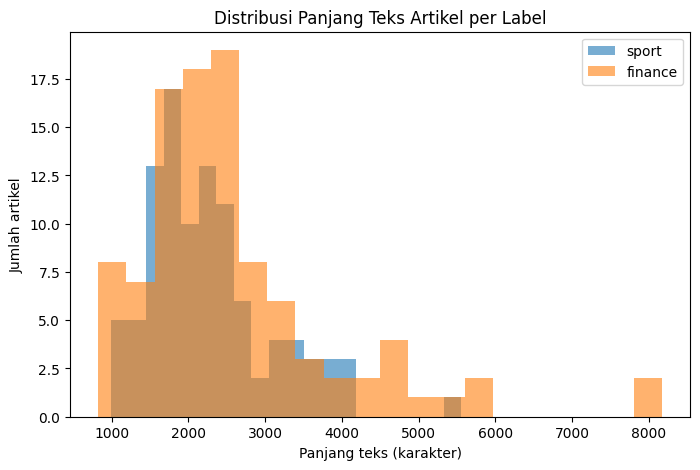

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
df[df["label"] == "sport"]["panjang_teks"].plot(kind="hist", alpha=0.6, bins=20, label="sport", ax=ax)
df[df["label"] == "finance"]["panjang_teks"].plot(kind="hist", alpha=0.6, bins=20, label="finance", ax=ax)
ax.set_xlabel("Panjang teks (karakter)")
ax.set_ylabel("Jumlah artikel")
ax.set_title("Distribusi Panjang Teks Artikel per Label")
ax.legend()
plt.show()

## Distribusi Sub-Kategori

In [9]:
import sys

!{sys.executable} -m pip install seaborn

     -------------------------------------- 294.9/294.9 kB 1.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


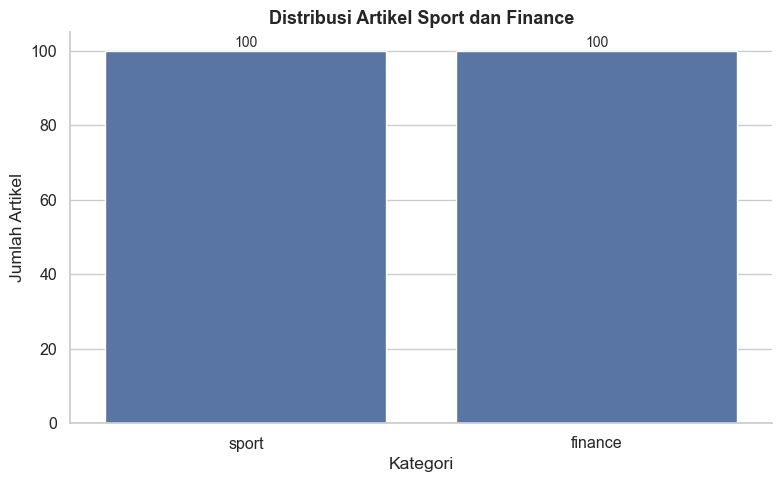

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.05)

# Menghitung jumlah artikel berdasarkan label
data = df["label"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=data.index,
    y=data.values
)

plt.title(
    "Distribusi Artikel Sport dan Finance",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Kategori")
plt.ylabel("Jumlah Artikel")

# Menampilkan jumlah di atas batang
for i, v in enumerate(data.values):
    plt.text(
        i,
        v + 1,
        str(v),
        ha="center",
        fontsize=10
    )

sns.despine()

plt.tight_layout()
plt.show()

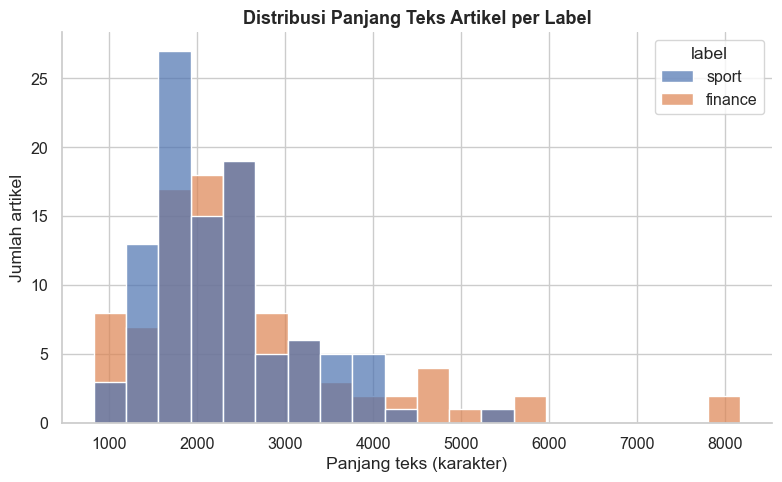

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="panjang_teks", hue="label",
             palette={"sport": "#4C72B0", "finance": "#DD8452"},
             bins=20, alpha=0.7, ax=ax)
ax.set_title("Distribusi Panjang Teks Artikel per Label", fontsize=13, fontweight="bold")
ax.set_xlabel("Panjang teks (karakter)")
ax.set_ylabel("Jumlah artikel")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Contoh Artikel

In [17]:
contoh_sport = df[df["label"]=="sport"].sample(1, random_state=1).iloc[0]
contoh_finance = df[df["label"]=="finance"].sample(1, random_state=1).iloc[0]

print("=== CONTOH ARTIKEL SPORT ===")
print(contoh_sport["isi_berita"][:400], "...\n")

print("=== CONTOH ARTIKEL FINANCE ===")
print(contoh_finance["isi_berita"][:400], "...")

=== CONTOH ARTIKEL SPORT ===
Bilal Hasan memulai debut di UFC dengan meyakinkan, menang KO. Legenda UFC, Henry Cejudo dibikin kagum olehnya.
UFC Fight Night: Nurmagomedov vs Song dalam UFC Shanghai digelar di Oriental Sports Center, Sabtu (29/8). Bilal Hasan yang jalani laga debut, hadapi petarung asal Peru, Nilson Rojas di kelas flyweight.
Kedua petarung punya rekor sama 9-0. Bilal menang di ronde kedua setelah pukulan lurus ...

=== CONTOH ARTIKEL FINANCE ===
Seluruh bandara yang sebelumnya terdampak erupsi Gunung Anak Krakatau kembali dibuka untuk operasional penerbangan. Berdasarkan pembaruan Kantor Otoritas Bandar Udara Wilayah I Kelas Utama, terdapat delapan bandara yang telah kembali beroperasi.
Informasi tersebut disampaikan melalui pembaruan operasional penerbangan per Selasa (8/9/2026) pukul 10.00 WIB. Pembukaan dilakukan setelah sebelumnya ope ...


## Ringkasan Data Understanding

- Dataset terdiri dari 200 artikel, seimbang antara kategori `sport` (100) dan `finance` (100).
- Tidak ditemukan nilai kosong maupun duplikat pada kolom `isi_berita`.
- Artikel sport didominasi sub-kategori seperti sepakbola dan basket, sementara finance didominasi berita ekonomi-bisnis dan moneter.
- Panjang artikel finance sedikit lebih panjang rata-rata dan lebih bervariasi dibanding sport, terlihat jelas dari histogram dan boxplot.
- Dataset dinyatakan **siap** untuk tahap Data Preparation.